# **PIPELINE IMPLEMENTATION**

What's a **pipeline**?

A **pipeline** is a way to chain multiple data preprocessing steps and a model together into a single object, so that data flows sequentially through each step — the output of one step becomes the input of the next. It ensures that preprocessing (like scaling, imputing, or encoding) is properly fit only on training data and consistently applied to test data, preventing data leakage. 

It also makes the code cleaner, more reusable, and easier to deploy, since the entire workflow can be treated and saved as a single object

Today, in this notebook our main agenda is to implement pipeline on data of titanic. doing some preprocessing and finally building a decision tree classifier.

In [203]:
# making our imports
import pandas as pd
import numpy as np

# sklearn imports
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, FunctionTransformer
from sklearn.metrics import accuracy_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns
# setting configuration to show diagrams
set_config(display='diagram')

Let's read our dataset and see what it have.

In [204]:
# Reading our data from csv and storing it in variable
df = pd.read_csv("/kaggle/input/datasets/abhinavralhan/titanic/train.csv")

# taking 10 samples out of data to see the content of data and decide further steps
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
59,60,0,3,"Goodwin, Master. William Frederick",male,11.0,5,2,CA 2144,46.9000,NaN,S
726,727,1,2,"Renouf, Mrs. Peter Henry (Lillian Jefferys)",female,30.0,3,0,31027,21.0000,NaN,S
343,344,0,2,"Sedgwick, Mr. Charles Frederick Waddington",male,25.0,0,0,244361,13.0000,NaN,S
687,688,0,3,"Dakic, Mr. Branko",male,19.0,0,0,349228,10.1708,NaN,S
122,123,0,2,"Nasser, Mr. Nicholas",male,32.5,1,0,237736,30.0708,NaN,C
618,619,1,2,"Becker, Miss. Marion Louise",female,4.0,2,1,230136,39.0000,F4,S
678,679,0,3,"Goodwin, Mrs. Frederick (Augusta Tyler)",female,43.0,1,6,CA 2144,46.9000,NaN,S
590,591,0,3,"Rintamaki, Mr. Matti",male,35.0,0,0,STON/O 2. 3101273,7.1250,NaN,S
731,732,0,3,"Hassan, Mr. Houssein G N",male,11.0,0,0,2699,18.7875,NaN,C
633,634,0,1,"Parr, Mr. William Henry Marsh",male,NaN,0,0,112052,0.0000,NaN,S


In [205]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [206]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


From the above table we observed that Fare column of our data have min 0 and max 512. which means that the data can be skewed. To observe if the data is skewed or not we plot a kde and qq plot.

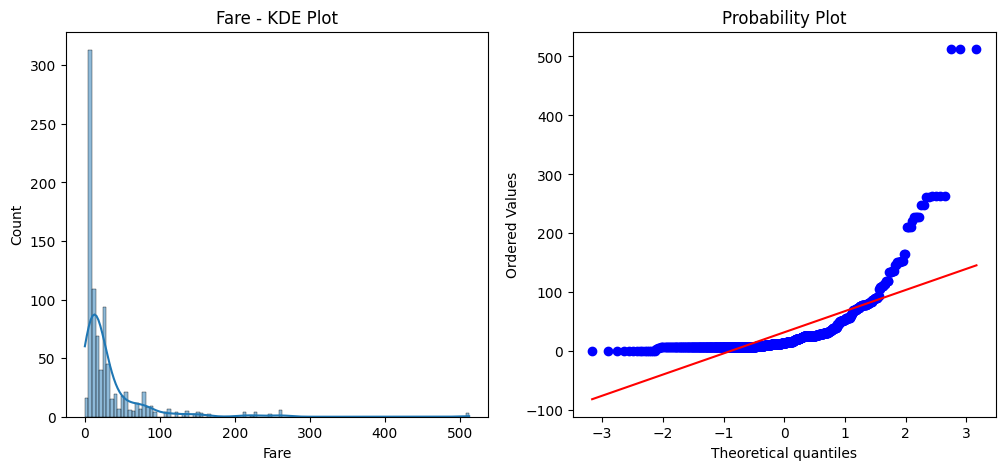

In [207]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# Plotting kdeplot
ax1.set_title("Fare - KDE Plot")
sns.histplot(df["Fare"], ax=ax1, kde=True)

# Plotting QQ Plot
ax2.set_title("Fare - QQ Plot")
stats.probplot(df["Fare"], plot=ax2)

plt.show()

Looking at these graphs we can see that our data is positively skewed forming a long tail in KDE plot toward right. which indicates that the data is posistively skewed.

## Planning

* **Step1** : Removing passengerid, name, ticket and cabin as these won't impact our model
* **Step2** : Splitting our data
* **Step3** : Preprocessing data using ColumnTransformer (Imputing, OneHotEncoding, FunctionTransforming)
* **Step4** : Applying MinMaxScaler on the dataset to squeeze data into common range
* **Step5** : Creating an object of DesicionTreeClassifie and LogisticRegression
* **Step6** : Creating Pipeline

Let's start our work...

## STEP 1 : Removing extra columns 

Removing PassengerId, Name, Ticket, Cabin

In [208]:
# Step 1 : Removing Passengerid, Name, Ticket and Cabin from our data
cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df.drop(columns=cols, inplace=True) # inplace = True updates your original data and return none. so, there's no need to reassign.
# taking a peek at our data after dropping
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


## STEP 2 : Splitting data

In this step, we will split our data into X, y (train and test).

In [210]:
# Seperating X_data and y_data
X_data = df.drop('Survived', axis=1)
y_data = df['Survived']

# Splitting our data
X_train, X_test, y_train, y_test = train_test_split(
    X_data,
    y_data,
    random_state = 0,
    train_size = 0.8,
    test_size = 0.2
)

X_data.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


## STEP 3 : Performing preprocessing using column transformer

In this step we'll perform imputation and encoding on our data in same column transformer

In [211]:
# Using Column Transformer to perform imputation
preprocessing = ColumnTransformer(
    [
        ('age_pipe', Pipeline([
            ('AgeImputer', SimpleImputer()),
            ('AgeTransformer', FunctionTransformer(func=np.log1p, validate=True))
         ]), 
         ['Age']
        ),
        ('embark_pipe', Pipeline([
            ('EmbarkedImputer', SimpleImputer(strategy='most_frequent')),
            ('Embarked_Encoder', OneHotEncoder(sparse_output=False, dtype=np.int32, handle_unknown='ignore'))
        ]),
        ['Embarked']
        ),
    ('sex_encoder', OneHotEncoder(sparse_output=False, dtype=np.int32, handle_unknown='ignore'), ['Sex']),
    ('fare_transformer', FunctionTransformer(func=np.log1p, validate=True), ['Fare'])
    ],
    remainder="passthrough"
)

## STEP 4 : Applying Normalization

In this step, we'll apply MinMaxScaler on our data. the purpose of this scaling is to center the data into same range.

In [212]:
# Using column Transformer to perform normalizations
min_max_scaler_transformer = ColumnTransformer(
    [('Scaler', MinMaxScaler(), slice(1,10))],
    remainder='passthrough'
)

## STEP 5 : Creating object of DecisionTreeClassifier And LogsiticRegression

In this step, we'll create the object for our DecisionTreeClassifier and LogisticRegression to put it into our Pipeline.

In [213]:
# Creating object of DecisionTreeClassifier
classifier = DecisionTreeClassifier()

# Creating object of DecisionTreeClassifier
logistic_classifier = LogisticRegression()

## STEP 6 : CREATING OUR PIPELINE

Now, let's create our pipeline by chaining all the above steps into one pipeline.

In [214]:
# Creating pipeline
pipeline = Pipeline([
    ('Preprocessing', preprocessing),
    ('Normalizer', min_max_scaler_transformer),
    ('Classifier', classifier)
])

pipeline_logistic = Pipeline([
    ('Preprocessing', preprocessing),
    ('Normalizer', min_max_scaler_transformer),
    ('Classifier', logistic_classifier)
])

In [217]:
# fitting/training our classifiers onto the training data
pipeline.fit(X_train, y_train)
pipeline_logistic.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('Preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('age_pipe',
                                                  Pipeline(steps=[('AgeImputer',
                                                                   SimpleImputer()),
                                                                  ('AgeTransformer',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>,
                                                                                       validate=True))]),
                                                  ['Age']),
                                                 ('embark_pipe',
                                                  Pipeline(steps=[('EmbarkedImputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('Embarked_Encoder',
                                                                   OneHot...
                                                 ('sex_encoder',
                                                  OneHotEncoder(dtype=<class 'numpy.int32'>,
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Sex']),
                                                 ('fare_transformer',
                                                  FunctionTransformer(func=<ufunc 'log1p'>,
                                                                      validate=True),
                                                  ['Fare'])])),
                ('Normalizer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Scaler', MinMaxScaler(),
                                                  slice(1, 10, None))])),
                ('Classifier', LogisticRegression())])

## STEP 7 : GENERATING PREDICTIONS AND CALCULATING ACCURACY

In [216]:
# Generating predicitons
y_pred = pipeline.predict(X_test)
y_pred_log = pipeline_logistic.predict(X_test)

# Calculating Accuracy
acc = accuracy_score(y_pred, y_test)
acc_log = accuracy_score(y_pred_log, y_test)

# Printing Accuracy
print(acc*100)
print(acc_log*100)

78.2122905027933
81.56424581005587


## CONCLUSION

In this notebook, we built a complete Pipeline — combining imputation, log transformation 
(to reduce skewness in Age and Fare), One-Hot Encoding, and MinMaxScaler — and trained two 
different classifiers on the same preprocessed data: a DecisionTreeClassifier and a 
LogisticRegression model.

Results:
* DecisionTreeClassifier: ~78.2% accuracy
* LogisticRegression: ~81.6% accuracy

Logistic Regression outperformed the Decision Tree here. This also makes the MinMaxScaler 
step more meaningful than before — scaling has no real effect on a Decision Tree's splits, 
but it directly helps a gradient-based model like Logistic Regression converge properly and 
treat features fairly.

This comparison highlights an important lesson: preprocessing choices (like scaling) aren't 
"one-size-fits-all" — their impact depends on which algorithm is being used downstream.